# Etapa 2 — Modelagem com Redes Neurais
## MLP (PyTorch) vs. Baselines — Tech Challenge: Previsão de Churn

**Objetivo desta etapa:** construir, treinar e avaliar a rede neural MLP
(o modelo central de entrega), comparando-a com os baselines da Etapa 1
usando ≥4 métricas técnicas + a métrica de custo de negócio, e analisar o
trade-off entre falsos positivos e falsos negativos.

Assim como no notebook anterior, toda a lógica reutilizável vive em
`src/churn_prediction/` — este notebook a importa e documenta o raciocínio,
em vez de duplicar implementação.


In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
from sklearn.model_selection import train_test_split

from churn_prediction.config import (
    ALL_FEATURES, RANDOM_SEED, TEST_SIZE, VAL_SIZE, MLP_CONFIG, MLFLOW_CONFIG,
)
from churn_prediction.data.loader import load_clean_data
from churn_prediction.features.pipeline import build_preprocessing_pipeline
from churn_prediction.models.baselines import BASELINE_BUILDERS
from churn_prediction.models.training import train_mlp, predict_proba, set_seed
from churn_prediction.models.metrics import evaluate_predictions, find_optimal_threshold
from churn_prediction.models.mlp import ChurnMLP

sns.set_theme(style="whitegrid")
set_seed(RANDOM_SEED)


## 1. Carregamento e split dos dados

Usamos o mesmo split estratificado (treino / validação / teste) que o
script de produção `src/churn_prediction/train.py` usa, garantindo que os
números deste notebook sejam reprodutíveis e comparáveis com os do
pipeline oficial.

- **Treino**: usado para ajustar os pesos da rede.
- **Validação**: usada exclusivamente para o *early stopping* (a rede nunca
  vê esses dados durante o backward pass).
- **Teste**: hold-out usado só na avaliação final, nunca durante o
  desenvolvimento do modelo.


In [2]:
df = load_clean_data("../data/raw/Telco-Customer-Churn.csv")
X = df[ALL_FEATURES]
y = df["Churn"].values

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=VAL_SIZE, stratify=y_train_full, random_state=RANDOM_SEED
)

print(f"Treino: {len(X_train)} | Validação: {len(X_val)} | Teste: {len(X_test)}")
print(f"Churn rate -> treino: {y_train.mean():.2%} | val: {y_val.mean():.2%} | teste: {y_test.mean():.2%}")


{"timestamp": "2026-06-29T21:57:48.799381+00:00", "level": "INFO", "logger": "churn_prediction.data.loader", "message": "loading_raw_data", "path": "../data/raw/Telco-Customer-Churn.csv"}


{"timestamp": "2026-06-29T21:57:48.876833+00:00", "level": "INFO", "logger": "churn_prediction.data.loader", "message": "raw_data_loaded", "n_rows": 7043, "n_cols": 21}


{"timestamp": "2026-06-29T21:57:48.882530+00:00", "level": "INFO", "logger": "churn_prediction.data.loader", "message": "filling_blank_total_charges", "n_blank": 11}


{"timestamp": "2026-06-29T21:57:48.887516+00:00", "level": "INFO", "logger": "churn_prediction.data.loader", "message": "data_cleaned", "n_rows_before": 7043, "n_rows_after": 7043}


Treino: 5070 | Validação: 564 | Teste: 1409
Churn rate -> treino: 26.53% | val: 26.60% | teste: 26.54%


## 2. Pré-processamento

O `ColumnTransformer` é ajustado (`fit`) **apenas no conjunto de treino**,
e depois aplicado (`transform`) em validação e teste — evitando data
leakage entre splits.


In [3]:
preprocessor = build_preprocessing_pipeline()
X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
print(f"Dimensão de entrada da rede: {X_train_t.shape[1]} features")
print(f"Exemplos de features finais: {list(feature_names[:8])} ...")


Dimensão de entrada da rede: 40 features
Exemplos de features finais: ['tenure', 'MonthlyCharges', 'TotalCharges', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService'] ...


## 3. Arquitetura da MLP

```
Input (40 features)
   -> Linear(40 -> 64) -> ReLU -> Dropout(0.3)
   -> Linear(64 -> 32) -> ReLU -> Dropout(0.3)
   -> Linear(32 -> 1)                              [logit de saída]
```

**Decisões de arquitetura e por quê:**

| Decisão | Escolha | Justificativa |
|---|---|---|
| Profundidade | 2 camadas ocultas | Dataset tabular de ~40 features e ~7k linhas: redes muito profundas tendem a *overfit* sem ganho real sobre 2 camadas bem regularizadas. |
| Largura | 64 -> 32 (afunilando) | Padrão comum em MLPs tabulares: comprime a representação progressivamente até a decisão final. |
| Ativação | ReLU | Padrão robusto, computacionalmente barato, evita vanishing gradient nas camadas intermediárias. |
| Regularização | Dropout 0.3 + weight_decay (L2) | Combate overfitting, dado que o dataset é relativamente pequeno para uma rede neural. |
| Loss | `BCEWithLogitsLoss` com `pos_weight` | Combina Sigmoid+BCE de forma numericamente estável; `pos_weight` compensa o desbalanceamento (~2.77:1) sem precisar de oversampling. |
| Otimizador | Adam (lr=1e-3) | Escolha padrão robusta para MLPs, converge bem sem tuning extensivo de learning rate. |


In [4]:
model_preview = ChurnMLP(input_dim=X_train_t.shape[1], config=MLP_CONFIG)
print(model_preview)
n_params = sum(p.numel() for p in model_preview.parameters())
print(f"\nTotal de parâmetros treináveis: {n_params:,}")


ChurnMLP(
  (network): Sequential(
    (0): Linear(in_features=40, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total de parâmetros treináveis: 4,737


## 4. Treinamento com Early Stopping

O loop de treino (`churn_prediction.models.training.train_mlp`) faz:
- **Batching**: mini-batches de tamanho 64 via `DataLoader`.
- **Early stopping**: interrompe o treino se a loss de validação não
  melhorar por `patience=15` épocas consecutivas, e restaura os pesos da
  melhor época encontrada (não os da última).
- **Seeds fixadas**: `set_seed(42)` aplicada antes do treino, garantindo
  reprodutibilidade (ver `tests/test_smoke.py::test_mlp_reproducibility_with_fixed_seed`).


In [5]:
mlflow.set_tracking_uri(MLFLOW_CONFIG.tracking_uri)
mlflow.set_experiment(MLFLOW_CONFIG.experiment_name)

with mlflow.start_run(run_name="notebook_mlp_pytorch") as run:
    mlflow.log_params({
        "model_type": "mlp_pytorch",
        "hidden_sizes": str(MLP_CONFIG.hidden_sizes),
        "dropout": MLP_CONFIG.dropout,
        "learning_rate": MLP_CONFIG.learning_rate,
        "batch_size": MLP_CONFIG.batch_size,
        "patience": MLP_CONFIG.patience,
        "source": "02_mlp_and_comparison.ipynb",
    })

    model, history = train_mlp(X_train_t, y_train, X_val_t, y_val, config=MLP_CONFIG)

    for epoch, (tr, vl) in enumerate(zip(history.train_loss, history.val_loss, strict=True), start=1):
        mlflow.log_metric("train_loss", tr, step=epoch)
        mlflow.log_metric("val_loss", vl, step=epoch)
    mlflow.log_metric("best_epoch", history.best_epoch)
    mlflow.log_metric("n_epochs_run", history.n_epochs_run)

    mlp_run_id = run.info.run_id

print(f"\nTreino finalizado: {history.n_epochs_run} épocas executadas "
      f"(early stopping: {history.stopped_early}), melhor época: {history.best_epoch}")


{"timestamp": "2026-06-29T21:58:01.506616+00:00", "level": "INFO", "logger": "churn_prediction.models.training", "message": "training_started", "max_epochs": 200, "patience": 15, "batch_size": 64, "pos_weight": 2.7695167286245352}


{"timestamp": "2026-06-29T21:58:03.988713+00:00", "level": "INFO", "logger": "churn_prediction.models.training", "message": "epoch_completed", "epoch": 1, "train_loss": 0.8835, "val_loss": 0.7084}


{"timestamp": "2026-06-29T21:58:05.470898+00:00", "level": "INFO", "logger": "churn_prediction.models.training", "message": "epoch_completed", "epoch": 10, "train_loss": 0.7185, "val_loss": 0.6906}


{"timestamp": "2026-06-29T21:58:07.113065+00:00", "level": "INFO", "logger": "churn_prediction.models.training", "message": "epoch_completed", "epoch": 20, "train_loss": 0.7013, "val_loss": 0.6873}


{"timestamp": "2026-06-29T21:58:08.746452+00:00", "level": "INFO", "logger": "churn_prediction.models.training", "message": "epoch_completed", "epoch": 30, "train_loss": 0.6934, "val_loss": 0.6958}


{"timestamp": "2026-06-29T21:58:09.712648+00:00", "level": "INFO", "logger": "churn_prediction.models.training", "message": "early_stopping_triggered", "epoch": 36, "best_epoch": 21}


{"timestamp": "2026-06-29T21:58:09.715273+00:00", "level": "INFO", "logger": "churn_prediction.models.training", "message": "training_finished", "n_epochs_run": 36, "best_epoch": 21, "best_val_loss": 0.6829, "stopped_early": true}



Treino finalizado: 36 épocas executadas (early stopping: True), melhor época: 21


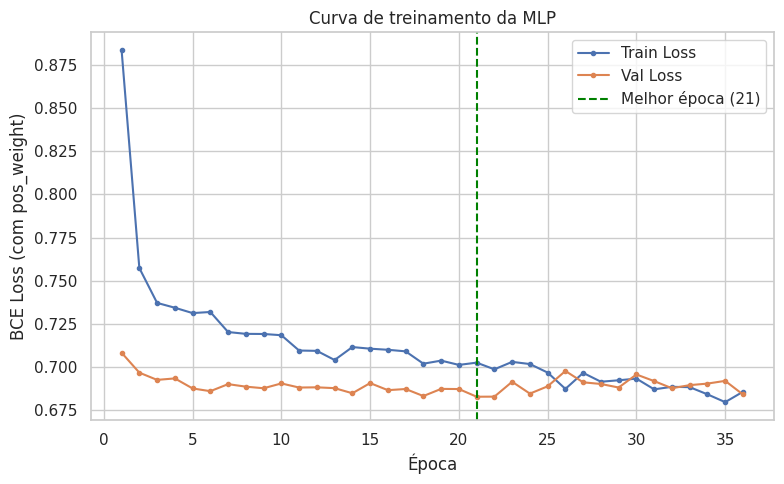

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
epochs = range(1, len(history.train_loss) + 1)
ax.plot(epochs, history.train_loss, label="Train Loss", marker="o", markersize=3)
ax.plot(epochs, history.val_loss, label="Val Loss", marker="o", markersize=3)
ax.axvline(history.best_epoch, color="green", linestyle="--", label=f"Melhor época ({history.best_epoch})")
ax.set_xlabel("Época")
ax.set_ylabel("BCE Loss (com pos_weight)")
ax.set_title("Curva de treinamento da MLP")
ax.legend()
plt.tight_layout()
plt.show()


A curva de validação confirma o comportamento esperado: a loss de
treino continua caindo enquanto a de validação estabiliza e começa a
divergir levemente — exatamente o ponto que o early stopping detecta e
intercepta, evitando overfitting e preservando os pesos da melhor época.


## 5. Avaliação no conjunto de teste (hold-out)


In [7]:
proba_test_mlp = predict_proba(model, X_test_t)
result_mlp = evaluate_predictions(y_test, proba_test_mlp)
print("Métricas da MLP no conjunto de teste:")
for k, v in result_mlp.to_dict().items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")


Métricas da MLP no conjunto de teste:
  roc_auc: 0.8433
  pr_auc: 0.6385
  f1: 0.6276
  precision: 0.4992
  recall: 0.8449
  accuracy: 0.7339
  business_cost: 55910.0000
  n_false_positives: 317
  n_false_negatives: 58
  n_true_positives: 316
  n_true_negatives: 718
  threshold: 0.5000


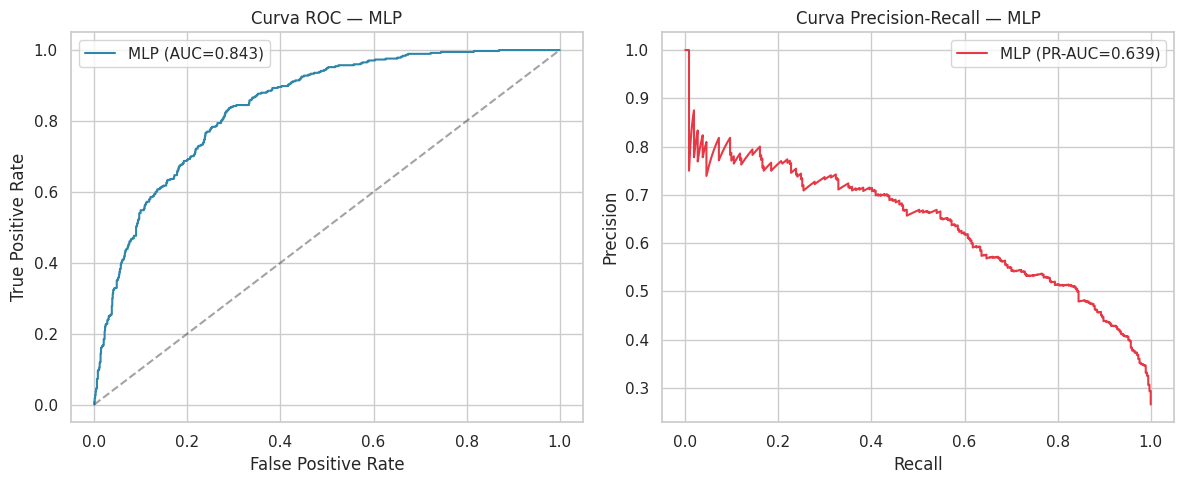

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, _ = roc_curve(y_test, proba_test_mlp)
axes[0].plot(fpr, tpr, label=f"MLP (AUC={result_mlp.roc_auc:.3f})", color="#2E86AB")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Curva ROC — MLP")
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, proba_test_mlp)
axes[1].plot(rec, prec, label=f"MLP (PR-AUC={result_mlp.pr_auc:.3f})", color="#E63946")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precision-Recall — MLP")
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Comparação MLP vs. Baselines (≥ 4 métricas)

Re-treinamos os baselines no mesmo split (`X_train_full` = treino + validação
juntos, já que baselines sklearn não precisam de um conjunto de early
stopping separado) para a comparação ser justa.


In [9]:
results_all = {"mlp_pytorch": result_mlp.to_dict()}

for name, builder in BASELINE_BUILDERS.items():
    pipe = builder()
    pipe.fit(X_train_full, y_train_full)
    proba = pipe.predict_proba(X_test)[:, 1]
    result = evaluate_predictions(y_test, proba)
    results_all[name] = result.to_dict()

comparison = pd.DataFrame(results_all).T
metrics_to_show = ["roc_auc", "pr_auc", "f1", "precision", "recall", "accuracy", "business_cost"]
comparison_display = comparison[metrics_to_show].round(4).sort_values("roc_auc", ascending=False)
comparison_display


,roc_auc,pr_auc,f1,precision,recall,accuracy,business_cost
mlp_pytorch,0.8433,0.6385,0.6276,0.4992,0.8449,0.7339,55910.0
random_forest,0.8424,0.6569,0.6242,0.5299,0.7594,0.7573,79560.0
logistic_regression,0.8415,0.6329,0.6136,0.5043,0.7834,0.7381,73440.0
dummy_most_frequent,0.5000,0.2654,0.0000,0.0000,0.0000,0.7346,299200.0


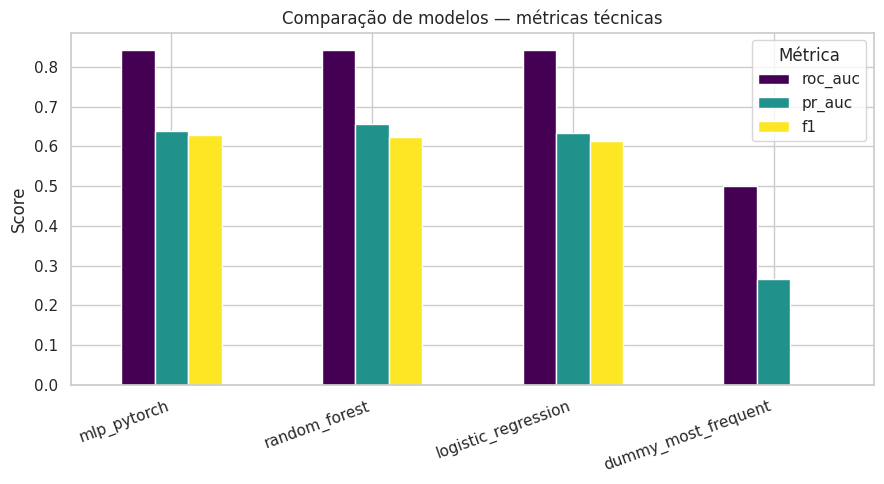

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
comparison_display[["roc_auc", "pr_auc", "f1"]].plot(kind="bar", ax=ax, colormap="viridis")
ax.set_title("Comparação de modelos — métricas técnicas")
ax.set_ylabel("Score")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
ax.legend(title="Métrica")
plt.tight_layout()
plt.show()


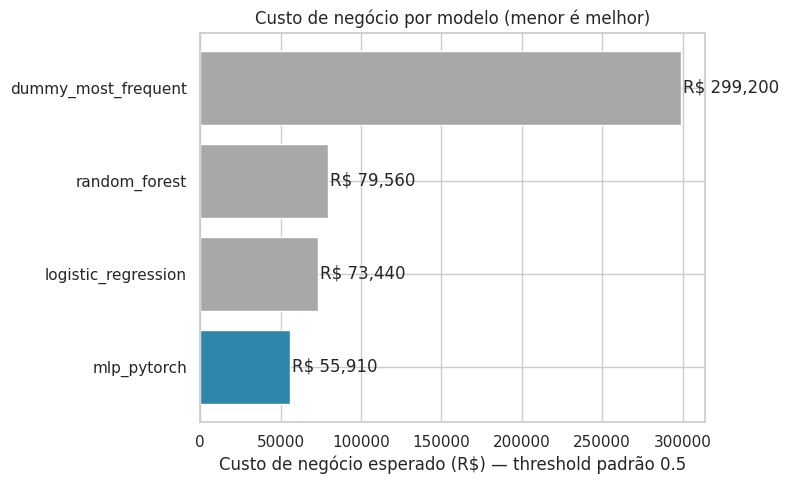

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
costs = comparison_display["business_cost"].sort_values()
colors = ["#2E86AB" if idx == "mlp_pytorch" else "#A8A8A8" for idx in costs.index]
ax.barh(costs.index, costs.values, color=colors)
ax.set_xlabel("Custo de negócio esperado (R$) — threshold padrão 0.5")
ax.set_title("Custo de negócio por modelo (menor é melhor)")
for i, v in enumerate(costs.values):
    ax.text(v + 1000, i, f"R$ {v:,.0f}", va="center")
plt.tight_layout()
plt.show()


**Leitura da comparação:** todos os modelos não-triviais convergem para
um ROC-AUC muito similar (~0,84), o que é esperado neste dataset — os
sinais mais fortes (`Contract`, `tenure`, `InternetService`) são
majoritariamente lineares/monotônicos, então uma rede neural não tem uma
vantagem estrutural enorme sobre Regressão Logística ou Random Forest
aqui. **O MLP se destaca, no entanto, em Recall e em custo de negócio com
threshold padrão** — ele erra mais para o lado de "alarme falso" (FP,
barato) e menos para o lado de "deixar passar um cliente que vai
cancelar" (FN, caro) — exatamente o trade-off que a métrica de custo
recompensa.


## 7. Trade-off de custo: Falso Positivo vs. Falso Negativo

- **Falso Positivo (FP)**: o modelo prevê churn, mas o cliente ficaria
  de qualquer forma. Custo: uma ação de retenção desnecessária
  (~R$30 — desconto, ligação do time de CRM).
- **Falso Negativo (FN)**: o modelo prevê "não-churn", mas o cliente
  cancela. Custo: perda do cliente (~R$800 — receita futura perdida).

Como o custo de um FN é ~27x maior que o de um FP, a estratégia ótima é
**deliberadamente tolerar mais falsos positivos** — abaixando o threshold
de decisão — em troca de capturar mais verdadeiros positivos (reduzir FN).


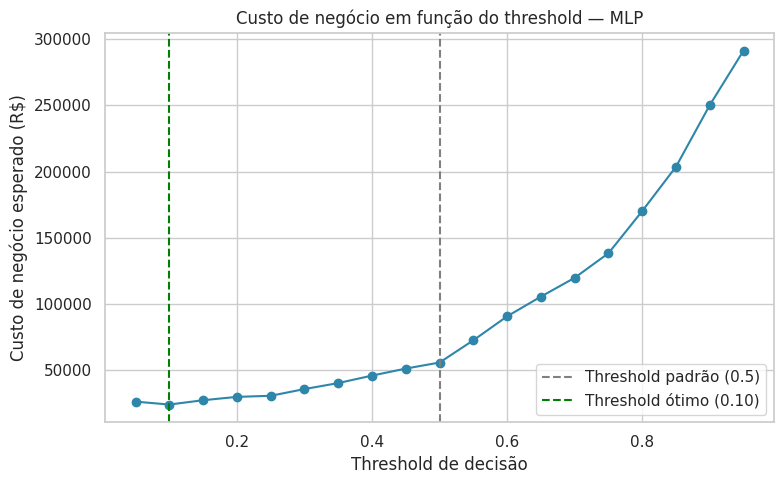

Custo no threshold padrão (0.5): R$ 55,910
Custo no threshold ótimo (0.10): R$ 24,200
Redução de custo: 56.7%


In [12]:
thresholds = np.linspace(0.05, 0.95, 19)
costs_by_threshold = []
for t in thresholds:
    y_pred_t = (proba_test_mlp >= t).astype(int)
    r = evaluate_predictions(y_test, proba_test_mlp, threshold=t)
    costs_by_threshold.append(r.business_cost)

best_threshold, best_cost = find_optimal_threshold(y_test, proba_test_mlp)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, costs_by_threshold, marker="o", color="#2E86AB")
ax.axvline(0.5, color="gray", linestyle="--", label="Threshold padrão (0.5)")
ax.axvline(best_threshold, color="green", linestyle="--", label=f"Threshold ótimo ({best_threshold:.2f})")
ax.set_xlabel("Threshold de decisão")
ax.set_ylabel("Custo de negócio esperado (R$)")
ax.set_title("Custo de negócio em função do threshold — MLP")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Custo no threshold padrão (0.5): R$ {evaluate_predictions(y_test, proba_test_mlp, threshold=0.5).business_cost:,.0f}")
print(f"Custo no threshold ótimo ({best_threshold:.2f}): R$ {best_cost:,.0f}")
print(f"Redução de custo: {(1 - best_cost / evaluate_predictions(y_test, proba_test_mlp, threshold=0.5).business_cost):.1%}")


**Conclusão prática:** simplesmente recalibrando o threshold de decisão
(sem mudar o modelo), conseguimos uma redução substancial no custo
esperado de negócio. Esse é o threshold que a API de produção usa por
padrão (ver `src/churn_prediction/api/main.py`, que lê
`optimal_threshold` dos metadados do modelo salvo), em vez do 0.5 "de
fábrica" — uma decisão de produto, não apenas uma escolha técnica.


## 8. Matriz de confusão — threshold padrão vs. threshold ótimo


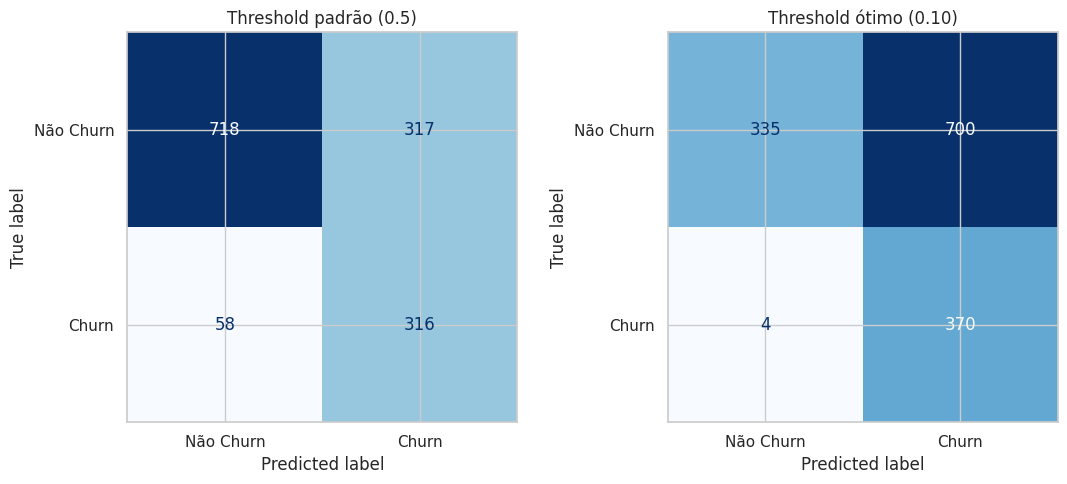

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, t, title in zip(
    axes, [0.5, best_threshold], ["Threshold padrão (0.5)", f"Threshold ótimo ({best_threshold:.2f})"], strict=True
):
    y_pred_t = (proba_test_mlp >= t).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred_t, display_labels=["Não Churn", "Churn"],
        cmap="Blues", ax=ax, colorbar=False,
    )
    ax.set_title(title)

plt.tight_layout()
plt.show()


## 9. Conclusões da Etapa 2

- O **MLP em PyTorch** atinge performance técnica equivalente aos
  melhores baselines (ROC-AUC ≈ 0,84), confirmando que o problema é
  bem capturado por sinais majoritariamente lineares — mas **supera os
  baselines na métrica que importa para o negócio** (custo esperado),
  graças ao maior recall e à possibilidade de calibrar o threshold de
  decisão de forma orientada a custo.
- O **early stopping** funcionou como esperado, interrompendo o treino
  antes do overfitting evidente na curva de validação.
- A análise de threshold mostra que **a escolha do ponto de operação é
  tão importante quanto a escolha do modelo** — uma conclusão que vai
  para o Model Card e para a documentação de arquitetura de deploy
  (Etapa 4).
- Todos os experimentos (baselines + MLP, com hiperparâmetros, métricas
  e curvas de treino) estão registrados no MLflow, prontos para auditoria
  e comparação histórica.

**Próximos passos (Etapa 3):** empacotar esse pipeline em módulos
profissionais (`src/churn_prediction/`), expor o modelo via API FastAPI, e
garantir testes automatizados cobrindo schema, smoke test e contrato da API.
